# Initialization

## Libraries

In [1]:
%load_ext autoreload
%autoreload 2

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import shap

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
from scipy import constants

c:\Users\giulio.barletta\mambaforge\envs\skoptim-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Directories

In [2]:
data_dir = Path("data")
Path.mkdir(data_dir, exist_ok=True)

plot_dir = Path("plots")
Path.mkdir(plot_dir, exist_ok=True)

log_dir = Path("logs")
Path.mkdir(log_dir, exist_ok=True)

## Data reading

In [3]:
data_file = "Dataset_SL.xlsx"

### Define experimental data

In [4]:
# 1. Define the experimental data
experiment_data = pd.read_excel(data_dir / data_file, sheet_name="Datasheet")

In [5]:
# make the other columns as floats
experiment_data = experiment_data.astype(
    {
        "salt_concentration": float,
        "water_to_cement_ratio": float,
        "antisettling_concentration": float,
        "E_d": float,
        "KPI": float,
    }
)

# get optimization round for later use in saving
opt_round = experiment_data["opt_round"].iloc[-1]

In [6]:
experiment_data.dropna(subset=["E_d"], inplace=True)
experiment_data = experiment_data[experiment_data["Notes"] != "Penalizzato"]
experiment_data

,opt_round,salt,salt_concentration,water_to_cement_ratio,antisettling_concentration,kernel,acquisition,obj_func,n_rejected_before_accept,E_d,KPI,Notes
0,0,MgSO4,0.50,1.00,0.00,NaN,NaN,NaN,NaN,39.392651,6.764730,NaN
1,0,CaCl2,0.50,1.00,0.00,NaN,NaN,NaN,NaN,91.053468,2.427368,NaN
2,0,SrBr2,0.50,1.00,0.00,NaN,NaN,NaN,NaN,159.169079,32.224874,NaN
3,0,MgCl2,0.50,1.00,0.00,NaN,NaN,NaN,NaN,88.671748,2.715363,NaN
4,0,CuSO4,0.50,1.00,0.00,NaN,NaN,NaN,NaN,9.658742,61.776688,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
97,4,MgCl2,0.15,1.25,0.00,RBF,EI,KPI,15.0,46.623793,4.038395,NaN
98,4,MgSO4,0.33,0.88,0.01,RBF,PI,KPI,34.0,23.165120,10.785614,NaN
99,4,MgCl2,0.55,1.07,1.07,RBF,LCB_low,KPI,8.0,57.119079,6.645415,NaN
100,4,Zn(NO3)2,0.16,1.24,1.04,RBF,LCB_med,KPI,4.0,41.951700,15.922248,NaN


# Energy Density

## Data preprocessing

In [7]:
X_data = experiment_data[
    [
        "salt",
        "salt_concentration",
        "water_to_cement_ratio",
        "antisettling_concentration",
    ]
]
y_data = experiment_data[["E_d"]]

### Binning to get stratified split

In [8]:
bins = np.squeeze(np.linspace(y_data.min(), y_data.max() + 0.1, 5))
y_binned = np.digitize(np.array(y_data), bins)

### Stratified train_test_split

In [9]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_binned
)

In [10]:
print(
    f"Train: mean = {np.mean(y_train, axis=0).values}, std = {np.std(y_train, axis=0).values}"
)
print(
    f"Test: mean = {np.mean(y_test, axis=0).values}, std = {np.std(y_test, axis=0).values}"
)

Train: mean = [88.97315624], std = [89.1543243]
Test: mean = [91.9571516], std = [90.59779432]


### Category encoding

In [11]:
# Define consistent categorical orders
cat_order = [
    "Al2(SO4)3",
    "CaCl2",
    "CuSO4",
    "K2CO3",
    "KAl(SO4)2",
    "LiCl",
    "Mg(NO3)2",
    "MgCl2",
    "MgSO4",
    "SrBr2",
    "Zn(NO3)2",
]

cat_mapping = {name: i for i, name in enumerate(cat_order)}

X_train_enc = X_train_raw.copy()
X_train_enc["salt_encoded"] = X_train_raw["salt"].map(cat_mapping)

X_test_enc = X_test_raw.copy()
X_test_enc["salt_encoded"] = X_test_raw["salt"].map(cat_mapping)

In [12]:
salt_dummies_train = pd.get_dummies(X_train_enc["salt"], prefix="salt").reindex(
    columns=[f"salt_{cat}" for cat in cat_order], fill_value=0
)

salt_dummies_test = pd.get_dummies(X_test_enc["salt"], prefix="salt").reindex(
    columns=[f"salt_{cat}" for cat in cat_order], fill_value=0
)

In [13]:
X_train = pd.concat(
    [
        salt_dummies_train.astype("float32"),
        X_train_raw[
            [
                "salt_concentration",
                "water_to_cement_ratio",
                "antisettling_concentration",
            ]
        ],
    ],
    axis=1,
)

X_test = pd.concat(
    [
        salt_dummies_test.astype("float32"),
        X_test_raw[
            [
                "salt_concentration",
                "water_to_cement_ratio",
                "antisettling_concentration",
            ]
        ],
    ],
    axis=1,
)

y_train = np.array(y_train).ravel()
y_test = np.array(y_test).ravel()

## Model

### Grid-search optimization

In [16]:
params = {
    "n_estimators": [50, 100, 200],
    "criterion": ["squared_error", "absolute_error", "friedman_mse"],
    "max_depth": [2, 5, 10],
    "random_state": [42],
}

rforest = RandomForestRegressor(n_jobs=-1)

gs = GridSearchCV(estimator=rforest, param_grid=params, scoring="r2", cv=5)

In [17]:
grid_result = gs.fit(X_train, y_train)

print(
    "Best score = {:.4f} using {}".format(
        grid_result.best_score_, grid_result.best_params_
    )
)

Best score = 0.3822 using {'criterion': 'absolute_error', 'max_depth': 10, 'n_estimators': 200, 'random_state': 42}


### Model performance

In [18]:
model = grid_result.best_estimator_

In [19]:
y_train_preds = model.predict(X_train)
y_test_preds = model.predict(X_test)

#### Training set

In [20]:
r2_train = r2_score(y_train, y_train_preds)
mae_train = mean_absolute_error(y_train, y_train_preds)
rmse_train = root_mean_squared_error(y_train, y_train_preds)

print(
    rf"Training metrics: $R^2$ = {r2_train:.3f}, MAE = {mae_train:.3f}, RMSE = {rmse_train:.3f}."
)

Training metrics: $R^2$ = 0.962, MAE = 11.676, RMSE = 17.425.


#### Test set

In [21]:
r2_test = r2_score(y_test, y_test_preds)
mae_test = mean_absolute_error(y_test, y_test_preds)
rmse_test = root_mean_squared_error(y_test, y_test_preds)

print(
    rf"Test metrics: $R^2$ = {r2_test:.3f}, MAE = {mae_test:.3f}, RMSE = {rmse_test:.3f}."
)

Test metrics: $R^2$ = 0.845, MAE = 28.866, RMSE = 35.662.


## Plot

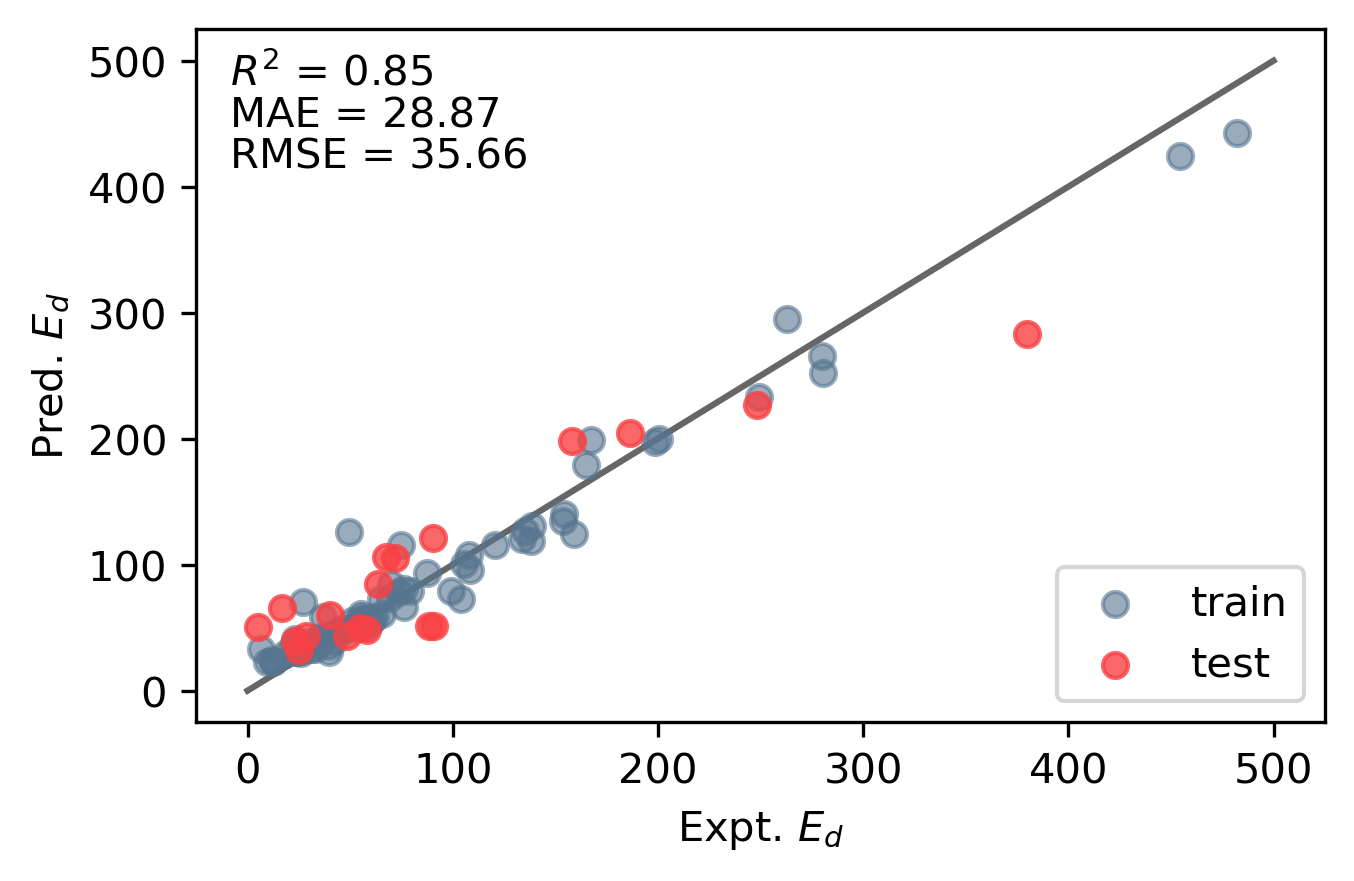

In [22]:
fig = plt.figure(figsize=(3 * constants.golden, 3), dpi=300)

plt.scatter(y_train, y_train_preds, c="#577590", alpha=0.6, label="train")
plt.scatter(y_test, y_test_preds, c="#f94144", alpha=0.8, label="test")

plt.plot([0, 500], [0, 500], c="#000000", alpha=0.6, zorder=-1)

plt.xlabel(r"Expt. $E_d$")
plt.ylabel(r"Pred. $E_d$")
plt.legend(loc="lower right")
plt.annotate(
    "$R^2$ = " + str(round(r2_test, 2)), xy=(0.03, 0.92), xycoords="axes fraction"
)
plt.annotate(
    "MAE = " + str(round(mae_test, 2)), xy=(0.03, 0.86), xycoords="axes fraction"
)
plt.annotate(
    "RMSE = " + str(round(rmse_test, 2)), xy=(0.03, 0.80), xycoords="axes fraction"
)

plt.savefig("plots/parity.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Feature importance

In [23]:
explainer = shap.TreeExplainer(model)
X = pd.concat([X_train, X_test])
shap_values = explainer.shap_values(X)

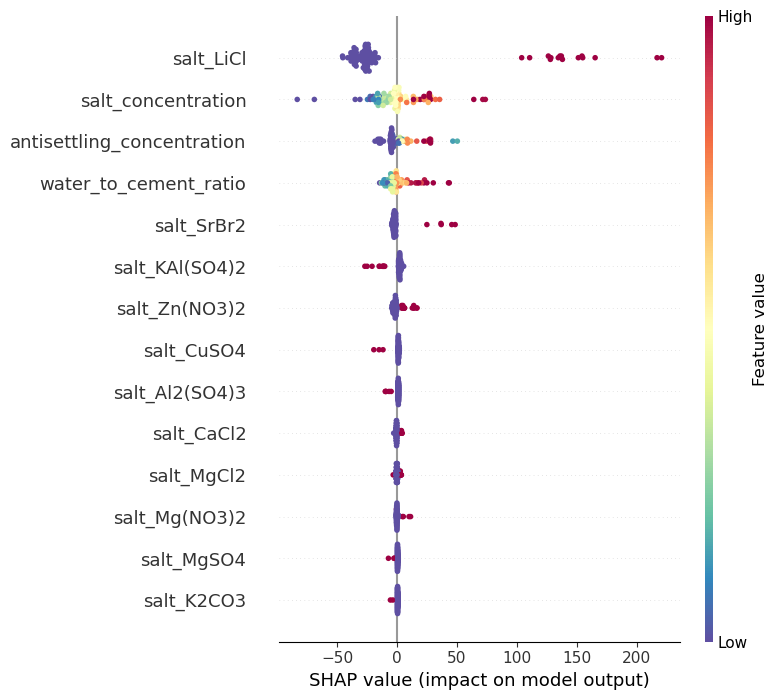

In [24]:
custom_colormap = [
    "#5e4fa2",
    "#3288bd",
    "#66c2a5",
    "#abdda4",
    "#e6f598",
    "#ffffbf",
    "#fee08b",
    "#fdae61",
    "#f46d43",
    "#d53e4f",
    "#9e0142",
]

my_cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    "my_custom_cmap", custom_colormap
)
shap.summary_plot(shap_values, X, cmap=my_cmap, show=False)
plt.savefig("plots/shap.pdf", dpi=300, bbox_inches="tight")
plt.show()